# Moody's-Style Daily Market Risk Monitor

This notebook generates a daily monitoring dashboard for:
- Equity risk (SPY, QQQ)
- Realized volatility (30D annualized)
- Drawdowns from peak
- Historical VaR (95%)
- Yield curve slope regime (10Y–2Y)
- Composite flag-based risk alerts

Data is ingested via an automated pipeline and stored in SQLite.
Derived metrics are computed programmatically and visualized below.

## Methodology

- 30D volatility = rolling standard deviation of daily returns × √252
- Drawdown = % decline from rolling peak
- VaR (95%) = historical 5th percentile of rolling returns
- Risk flags triggered when thresholds are breached
- Yield curve inversion = 10Y Treasury – 2Y Treasury < 0

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

DB_PATH = "data.sqlite"
conn = sqlite3.connect(DB_PATH)

prices = pd.read_sql_query(
    "SELECT symbol, date, close FROM prices WHERE symbol IN ('SPY','QQQ') ORDER BY date",
    conn
)

metrics = pd.read_sql_query(
    "SELECT * FROM derived_metrics WHERE symbol IN ('SPY','QQQ') ORDER BY date",
    conn
)

stress = pd.read_sql_query(
    "SELECT * FROM market_stress ORDER BY date",
    conn
)

conn.close()

prices["date"] = pd.to_datetime(prices["date"])
metrics["date"] = pd.to_datetime(metrics["date"])
stress["date"] = pd.to_datetime(stress["date"])

prices.tail()

,symbol,date,close
6874,SPY,2026-02-18,686.29
6875,QQQ,2026-02-19,603.47
6876,SPY,2026-02-19,684.48
6877,QQQ,2026-02-20,608.81
6878,SPY,2026-02-20,689.43


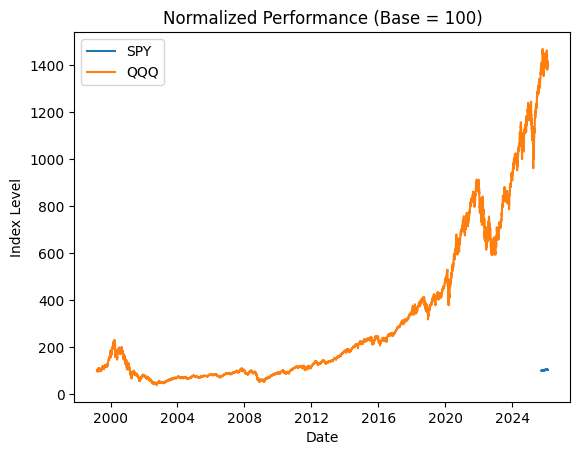

In [2]:
plt.figure()

for sym in ["SPY", "QQQ"]:
    df = prices[prices["symbol"] == sym].copy()
    df = df.sort_values("date")
    df["norm"] = df["close"] / df["close"].iloc[0] * 100
    plt.plot(df["date"], df["norm"], label=sym)

plt.title("Normalized Performance (Base = 100)")
plt.xlabel("Date")
plt.ylabel("Index Level")
plt.legend()
plt.show()

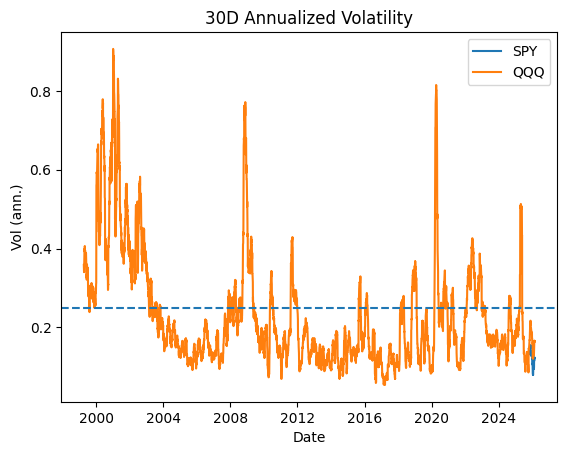

In [3]:
plt.figure()
for sym in ["SPY", "QQQ"]:
    df = metrics[metrics["symbol"] == sym].dropna(subset=["vol_30d_ann"])
    plt.plot(df["date"], df["vol_30d_ann"], label=sym)
plt.title("30D Annualized Volatility")
plt.xlabel("Date")
plt.ylabel("Vol (ann.)")
plt.legend()
plt.axhline(0.25, linestyle="--")
plt.show()


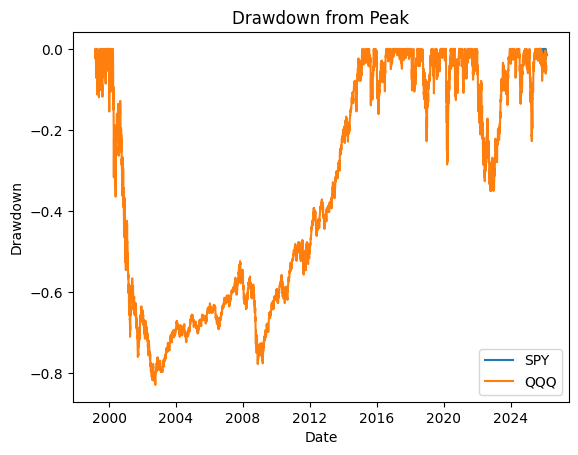

In [4]:
plt.figure()
for sym in ["SPY", "QQQ"]:
    df = metrics[metrics["symbol"] == sym].dropna(subset=["drawdown"])
    plt.plot(df["date"], df["drawdown"], label=sym)
plt.title("Drawdown from Peak")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.legend()
plt.show()

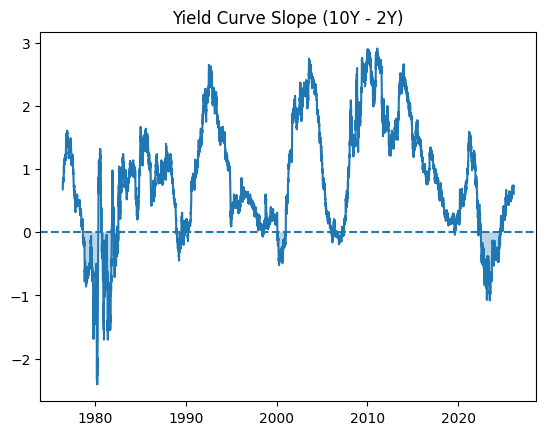

In [5]:
plt.figure()
plt.plot(stress["date"], stress["slope_10y_2y"])
plt.axhline(0, linestyle="--")
plt.fill_between(
    stress["date"],
    stress["slope_10y_2y"],
    0,
    where=stress["slope_10y_2y"] < 0,
    alpha=0.3
)
plt.title("Yield Curve Slope (10Y - 2Y)")
plt.show()

In [6]:
watchlist = pd.read_csv("outputs/daily_watchlist.csv")

In [7]:
latest_date = watchlist["date"].max()
today = watchlist[watchlist["date"] == latest_date].copy()

print("DATE:", latest_date)
display(today.sort_values("flags_count", ascending=False))

top = today.sort_values("flags_count", ascending=False).iloc[0]
print("\nKey takeaway:")
print(f"- Highest flags: {top['symbol']} (flags_count={int(top['flags_count'])})")

DATE: 2026-02-20


,symbol,date,return_1d,vol_30d_ann,drawdown,var_95,flag_vol,flag_dd,flag_var,flags_count
0,QQQ,2026-02-20,0.008849,0.164969,-0.042405,-0.020976,True,True,False,2
1,SPY,2026-02-20,0.007232,0.121983,-0.008713,-0.012765,False,False,False,0



Key takeaway:
- Highest flags: QQQ (flags_count=2)


### Daily Risk Interpretation

As of 2026-02-20:

- QQQ triggered 2 risk flags (volatility & drawdown)
- SPY shows no active risk signals
- Yield curve slope remains positive (~0.6), indicating no inversion regime
- No broad macro stress signal detected

Risk appears concentrated in higher-beta technology exposure rather than systemic market stress.

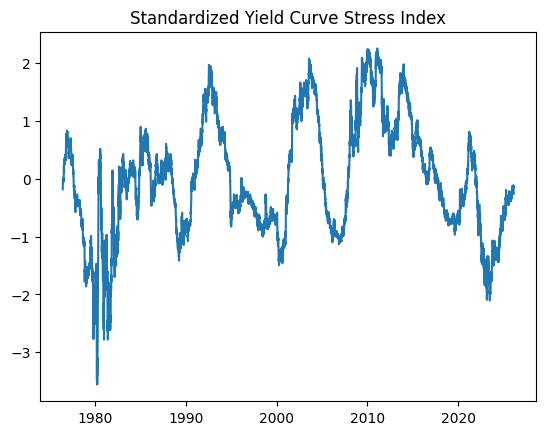

In [8]:
stress["z_slope"] = (stress["slope_10y_2y"] - stress["slope_10y_2y"].mean()) / stress["slope_10y_2y"].std()

plt.figure()
plt.plot(stress["date"], stress["z_slope"])
plt.title("Standardized Yield Curve Stress Index")
plt.show()

## Conclusion

As of the latest observation:

- No systemic macro stress detected
- Yield curve slope remains positive
- Risk flags are concentrated in higher-beta tech exposure (QQQ)
- Broad market (SPY) remains stable

The system successfully differentiates localized risk from systemic regime shifts.